# 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, 
    fbeta_score,          
    confusion_matrix, 
    precision_recall_curve,
    auc,
    accuracy_score
)

import catboost as cb
import optuna
from optuna.samplers import TPESampler

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# 2. LOAD DATASET & PREPROCESS

In [2]:
# 2. LOAD DATASET & PREPROCESS
DATA_PATH = '/kaggle/input/datasets/advaithsrao/enron-fraud-email-dataset/enron_data_fraud_labeled.csv'

df = pd.read_csv(DATA_PATH)
print("✅ Real Dataset loaded successfully!")
print(f"Available columns in the CSV: {df.columns.tolist()}")
    
# Smart-detect the Text column
text_candidates = ['Text', 'text', 'Message', 'message', 'content', 'Content', 'body', 'Body', 'email', 'Email']
TEXT_COL = next((col for col in text_candidates if col in df.columns), df.columns[0])
    
# Smart-detect the Target/Class column
target_candidates = ['Class', 'class', 'Label', 'label', 'Fraud', 'fraud', 'is_fraud', 'target', 'Target']
TARGET_COL = next((col for col in target_candidates if col in df.columns), df.columns[-1])

print(f"➡️ Auto-selected Text Column: '{TEXT_COL}'")
print(f"➡️ Auto-selected Target Column: '{TARGET_COL}'\n")

    

# Drop rows with missing values in our target column
df = df.dropna(subset=[TARGET_COL])
df[TARGET_COL] = df[TARGET_COL].astype(int)

# Identify available metadata columns
meta_candidates = ['Subject', 'From', 'To', 'Date', 'Sender-Type']
available_meta = [col for col in meta_candidates if col in df.columns]

# Separate them logically into Text vs Categorical
text_cols = [TEXT_COL]
if 'Subject' in available_meta:
    text_cols.append('Subject')

cat_cols = [col for col in available_meta if col != 'Subject']

# Fill NaNs appropriately based on feature type
for col in text_cols:
    df[col] = df[col].fillna("")
for col in cat_cols:
    df[col] = df[col].fillna("Missing").astype(str) # Categoricals need to be strings

# PREPROCESSING
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)
    text = re.sub(r'<[^>]*>', '', text)
    return text.strip()

# Apply text preprocessing ONLY to the text columns
for col in text_cols:
    df[col] = df[col].apply(preprocess_text)

# Train-Test Split (Stratified)
features = text_cols + cat_cols
X = df[features]
y = df[TARGET_COL]

# First split: 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# Second split: Divide Temp evenly into Validation (15%) and Test (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Final Data Shapes -> Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print(f"Text Features: {text_cols}")
print(f"Categorical Features: {cat_cols}")

✅ Real Dataset loaded successfully!
Available columns in the CSV: ['Folder-User', 'Folder-Name', 'Message-ID', 'Date', 'From', 'To', 'Subject', 'Mime-Version', 'Content-Type', 'Content-Transfer-Encoding', 'X-From', 'X-To', 'X-cc', 'X-bcc', 'X-Folder', 'X-Origin', 'X-FileName', 'Body', 'Cc', 'Bcc', 'Time', 'Attendees', 'Re', 'Source', 'Mail-ID', 'POI-Present', 'Suspicious-Folders', 'Sender-Type', 'Unique-Mails-From-Sender', 'Low-Comm', 'Contains-Reply-Forwards', 'Label']
➡️ Auto-selected Text Column: 'Body'
➡️ Auto-selected Target Column: 'Label'

Final Data Shapes -> Train: 313191 | Val: 67113 | Test: 67113
Text Features: ['Body', 'Subject']
Categorical Features: ['From', 'To', 'Date', 'Sender-Type']


# 3. OPTUNA TUNING (Maximizing F2 Score on GPU)

In [3]:
# 3. OPTUNA TUNING (Maximizing F2 Score on GPU)
print("\n--- Starting Optuna Tuning (100 Trials on GPU) ---")

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'auto_class_weights': trial.suggest_categorical('auto_class_weights', ['None', 'Balanced', 'SqrtBalanced']),
        'random_seed': 42,
        'task_type': 'GPU',        
        'eval_metric': 'Logloss', 
        'logging_level': 'Silent'
    }
    
    # Update Pools to map CatBoost directly to the distinct text and categorical columns
    train_pool = cb.Pool(X_train, y_train, text_features=text_cols, cat_features=cat_cols)
    val_pool = cb.Pool(X_val, y_val, text_features=text_cols, cat_features=cat_cols)
    
    model = cb.CatBoostClassifier(**params)
    
    model.fit(
        train_pool, 
        eval_set=val_pool, 
        early_stopping_rounds=30   
    )
    
    # Predict on validation set
    preds = model.predict(val_pool)
    preds = [int(p) for p in preds] 
    
    # Calculate Metrics
    f2 = fbeta_score(y_val, preds, beta=2.0)
    acc = accuracy_score(y_val, preds)
    
    # Print Accuracy beside F2 Score for monitoring
    print(f"--> Trial {trial.number} | F2 Score: {f2:.4f} | Val Accuracy: {acc:.4f}")
    
    return f2

# Create the study
study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))

study.enqueue_trial({
    'iterations': 927,
    'learning_rate': 0.06032227339365829,
    'depth': 9,
    'l2_leaf_reg': 8.172661205220175,
    'auto_class_weights': 'SqrtBalanced'
})

# Run optimization
study.optimize(objective, n_trials=100)   

print("\nBest Trial:")
print(" Value (F2 Score):", study.best_value)
print(" Params:")
for key, value in study.best_trial.params.items():
    print(f"    {key}: {value}")

[I 2026-03-18 22:11:38,043] A new study created in memory with name: no-name-cad1578e-4075-44b5-8bd5-7d55d810ad96



--- Starting Optuna Tuning (100 Trials on GPU) ---


[I 2026-03-18 22:12:48,069] Trial 0 finished with value: 0.8107403545359749 and parameters: {'iterations': 927, 'learning_rate': 0.06032227339365829, 'depth': 9, 'l2_leaf_reg': 8.172661205220175, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 0 with value: 0.8107403545359749.


--> Trial 0 | F2 Score: 0.8107 | Val Accuracy: 0.9963


[I 2026-03-18 22:13:46,700] Trial 1 finished with value: 0.7753537735849056 and parameters: {'iterations': 500, 'learning_rate': 0.07969454818643935, 'depth': 9, 'l2_leaf_reg': 0.24810409748678125, 'auto_class_weights': 'None'}. Best is trial 0 with value: 0.8107403545359749.


...

--> Trial 97 | F2 Score: 0.8077 | Val Accuracy: 0.9962


[I 2026-03-18 23:35:43,645] Trial 98 finished with value: 0.8103896103896104 and parameters: {'iterations': 771, 'learning_rate': 0.04381829115246218, 'depth': 10, 'l2_leaf_reg': 5.311132826648717, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 70 with value: 0.8164326573062922.


--> Trial 98 | F2 Score: 0.8104 | Val Accuracy: 0.9962


[I 2026-03-18 23:36:33,534] Trial 99 finished with value: 0.8041237113402062 and parameters: {'iterations': 814, 'learning_rate': 0.03108198281481202, 'depth': 10, 'l2_leaf_reg': 6.362481893720589, 'auto_class_weights': 'SqrtBalanced'}. Best is trial 70 with value: 0.8164326573062922.


--> Trial 99 | F2 Score: 0.8041 | Val Accuracy: 0.9960

Best Trial:
 Value (F2 Score): 0.8164326573062922
 Params:
    iterations: 322
    learning_rate: 0.0300087526595692
    depth: 9
    l2_leaf_reg: 2.1511111235875124
    auto_class_weights: SqrtBalanced


# 4. TRAIN FINAL MODEL & EVALUATE

In [4]:
# 4. TRAIN FINAL MODEL & EVALUATE
print("\n--- Training Final Model ---")

best_params = study.best_trial.params
best_params.update({
    'random_seed': 42,
    'task_type': 'GPU',
    'eval_metric': 'Logloss',
    'logging_level': 'Verbose',
    'metric_period': 50,
    
    'dictionaries': [
        {'dictionary_id': 'Word', 'occurrence_lower_bound': '1'},
        {'dictionary_id': 'BiGram', 'occurrence_lower_bound': '1', 'gram_order': '2'}
    ]
})

final_model = cb.CatBoostClassifier(**best_params)

train_pool = cb.Pool(X_train, y_train, text_features=text_cols, cat_features=cat_cols)
val_pool = cb.Pool(X_val, y_val, text_features=text_cols, cat_features=cat_cols)
test_pool = cb.Pool(X_test, y_test, text_features=text_cols, cat_features=cat_cols)

final_model.fit(
    train_pool, 
    eval_set=val_pool, 
    early_stopping_rounds=50
)


--- Training Final Model ---
0:	learn: 0.5791802	test: 0.5784367	best: 0.5784367 (0)	total: 62.1ms	remaining: 19.9s
50:	learn: 0.0347057	test: 0.0325529	best: 0.0325529 (50)	total: 3.21s	remaining: 17s
100:	learn: 0.0280586	test: 0.0296156	best: 0.0296156 (100)	total: 6.04s	remaining: 13.2s
150:	learn: 0.0252661	test: 0.0287709	best: 0.0287593 (146)	total: 8.77s	remaining: 9.93s
200:	learn: 0.0231844	test: 0.0285323	best: 0.0285056 (192)	total: 11.5s	remaining: 6.9s
250:	learn: 0.0214207	test: 0.0282989	best: 0.0282989 (250)	total: 14.2s	remaining: 4s
300:	learn: 0.0198740	test: 0.0281689	best: 0.0281602 (296)	total: 16.9s	remaining: 1.18s
321:	learn: 0.0192750	test: 0.0281794	best: 0.0281304 (310)	total: 18s	remaining: 0us
bestTest = 0.02813044956
bestIteration = 310
Shrink model to first 311 iterations.


# 5. FINAL METRICS & GRAPHS


--- Final Model Evaluation on Unseen Test Set ---

Final Test F2 Score: 0.8316

Classification Report:
              precision    recall  f1-score   support

           0     0.9995    0.9970    0.9983     66764
           1     0.6163    0.9112    0.7353       349

    accuracy                         0.9966     67113
   macro avg     0.8079    0.9541    0.8668     67113
weighted avg     0.9975    0.9966    0.9969     67113



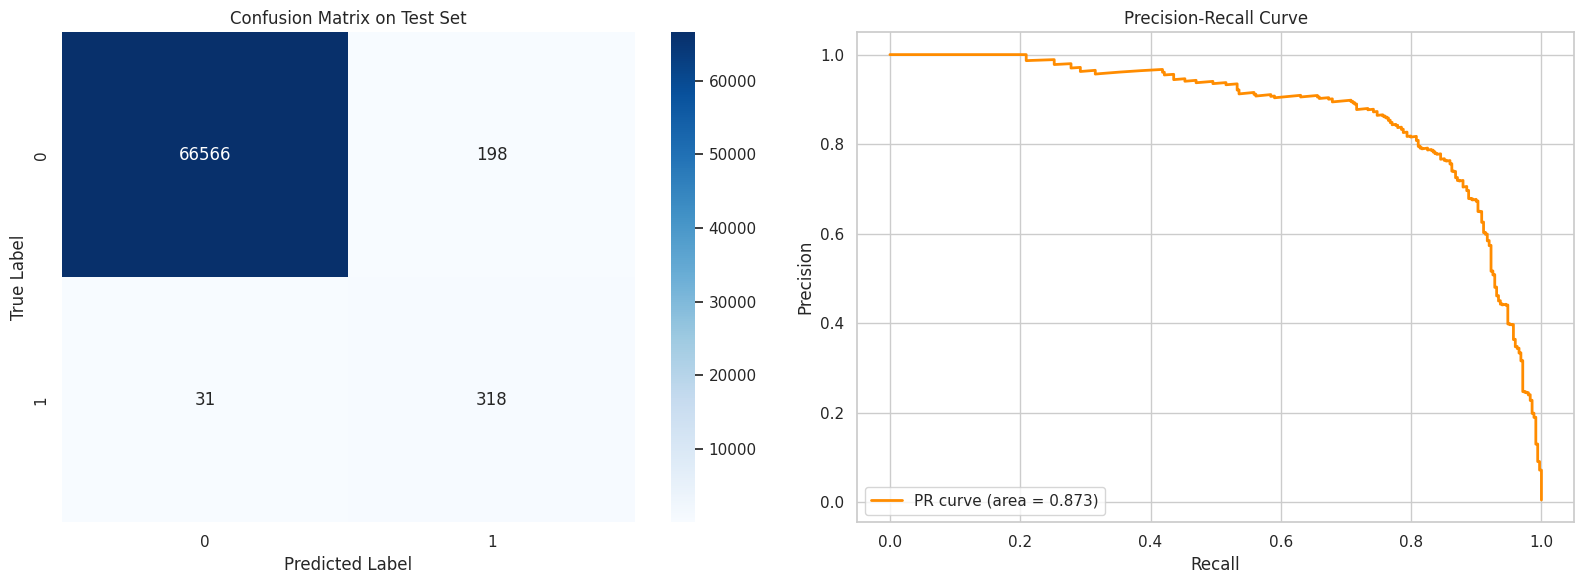

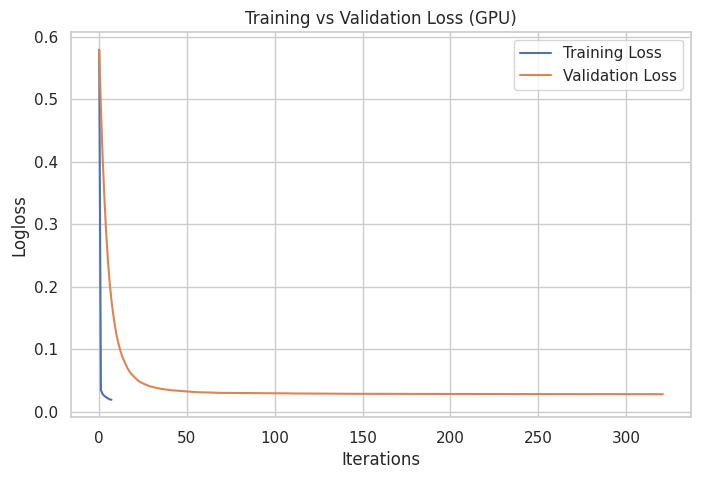

In [5]:
print("\n--- Final Model Evaluation on Unseen Test Set ---")
y_pred = final_model.predict(test_pool)
y_pred = [int(p) for p in y_pred]
y_proba = final_model.predict_proba(test_pool)[:, 1]

# Display the F2 Score explicitly
final_f2 = fbeta_score(y_test, y_pred, beta=2.0)
print(f"\nFinal Test F2 Score: {final_f2:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix on Test Set')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# Precision-Recall Curve 
precision, recall_vals, thresholds = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall_vals, precision)

axes[1].plot(recall_vals, precision, color='darkorange', lw=2, label=f'PR curve (area = {pr_auc:0.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

# Learning Curve (Overfitting Check)
evals_result = final_model.get_evals_result()
if 'Logloss' in evals_result['learn']:
    plt.figure(figsize=(8, 5))
    plt.plot(evals_result['learn']['Logloss'], label='Training Loss')
    plt.plot(evals_result['validation']['Logloss'], label='Validation Loss')
    plt.title('Training vs Validation Loss (GPU)')
    plt.xlabel('Iterations')
    plt.ylabel('Logloss')
    plt.legend()
    plt.show()